<a href="https://colab.research.google.com/github/HemenDishri/IITM/blob/main/Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
def factors(n):
  f1=[]
  for i in range (1,n+1):
    if n%i==0:
      f1.append(i)
  return f1

In [ ]:
factors(111)

[1, 3, 37, 111]

In [ ]:
def prime(n):
    return(factors(n) == [1,n])

In [ ]:
prime(211)

True

In [ ]:
def twin(n):
    if prime(n) and prime(n+2):
        return True
    else:
        return False

In [ ]:
for i in range(100):
    if twin(i):
        print(i,i+2)

3 5
5 7
11 13
17 19
29 31
41 43
59 61
71 73


In [ ]:
# prompt: Object oriented programming training

class Numbers:
    def __init__(self, number):
        self.number = number

    def factors(self):
        f1 = []
        for i in range(1, self.number + 1):
            if self.number % i == 0:
                f1.append(i)
        return f1

    def is_prime(self):
        return self.factors() == [1, self.number]

class Primes(Numbers):
    def is_twin(self):
        if self.is_prime():
            # Check if number + 2 is prime
            twin_candidate = Numbers(self.number + 2)
            return twin_candidate.is_prime()
        else:
            return False

# Example Usage
for i in range(100):
    num_obj = Primes(i)
    if num_obj.is_twin():
        print(i, i + 2)
```

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

data = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [7]:
data.isna().sum()

,0
Location,0
Cross_Street,16552
Latitude,0
Longitude,0
Date_Reported,0
Date_Occurred,0
Time_Occurred,0
Area_ID,0
Area_Name,0
Reporting_District_no,0


In [8]:
data['Modus_Operandi'].nunique()

10489

In [5]:
# prompt: create the frequency distribution of each category of the data

data['Modus_Operandi'].value_counts()

,count
Modus_Operandi,
0344,826
0329,583
1501,187
0329 1300,135
0325,127
...,...
2034,1
2000 0419 0444 1814 0913,1
0913 1402 0421 0334 2000 1814,1


In [6]:
negative_age_count = data[data['Victim_Age'] < 0]['Victim_Age'].count()

In [8]:
print(negative_age_count)

6


In [2]:
import pandas as pd

In [4]:
#card_data = pd.read_csv("./card_transdata.csv", header = 0, sep=",")

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
card_data= pd.read_csv("card_transdata.csv")


In [5]:
card_data = pd.get_dummies(card_data, columns=['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order'], drop_first=False)
card_data

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,fraud,repeat_retailer_N,repeat_retailer_Y,used_chip_N,used_chip_Y,used_pin_number_N,used_pin_number_Y,online_order_N,online_order_Y
0,57.877857,0.311140,1.945940,0,False,True,False,True,True,False,True,False
1,10.829943,0.175592,1.294219,0,False,True,True,False,True,False,True,False
2,5.091079,0.805153,0.427715,0,False,True,True,False,True,False,False,True
3,2.247564,5.600044,0.362663,0,False,True,False,True,True,False,False,True
4,44.190936,0.566486,2.222767,0,False,True,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2.207101,0.112651,1.626798,0,False,True,False,True,True,False,True,False
999996,19.872726,2.683904,2.778303,0,False,True,False,True,True,False,True,False
999997,2.914857,1.472687,0.218075,0,False,True,False,True,True,False,False,True
999998,4.258729,0.242023,0.475822,0,False,True,True,False,True,False,False,True


In [6]:
from sklearn.model_selection import train_test_split

# Separate features and labels
X = card_data.drop(columns=['fraud'])  # Features
y = card_data['fraud']  # Labels

# Split the data into train and test samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800000, 11), (200000, 11), (800000,), (200000,))

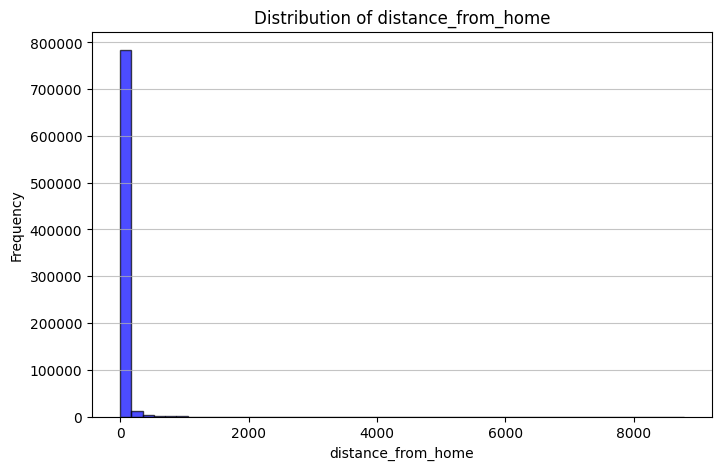

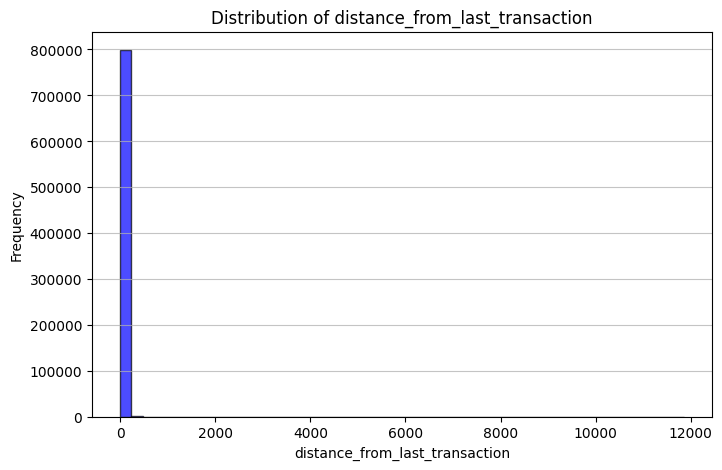

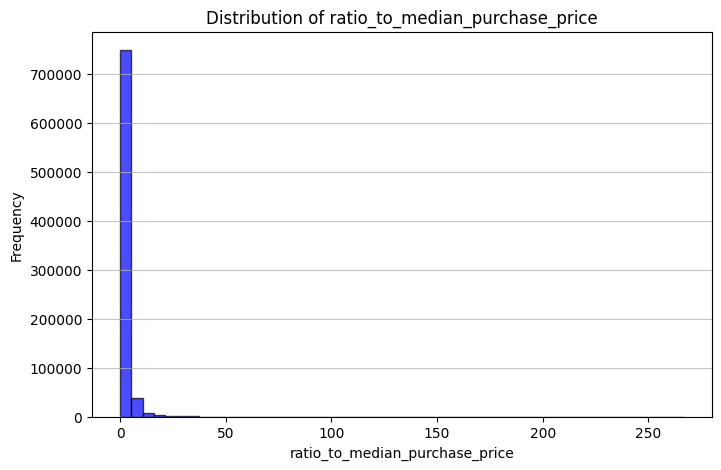

In [8]:
import matplotlib.pyplot as plt

# List of numerical columns
numerical_columns = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

# Plot histograms for each numerical column
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(X_train[column], bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

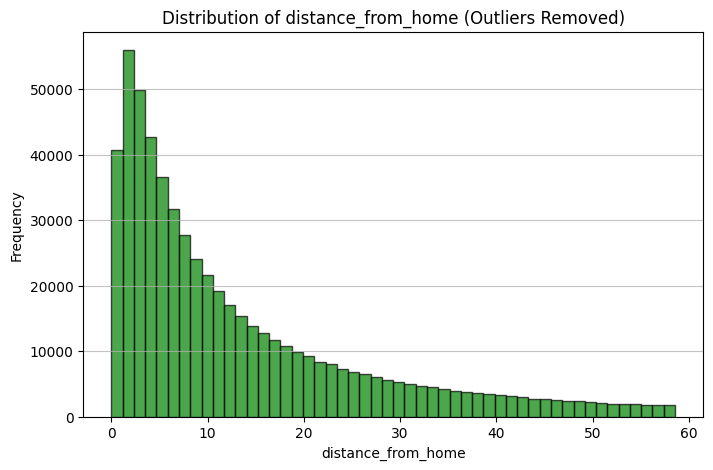

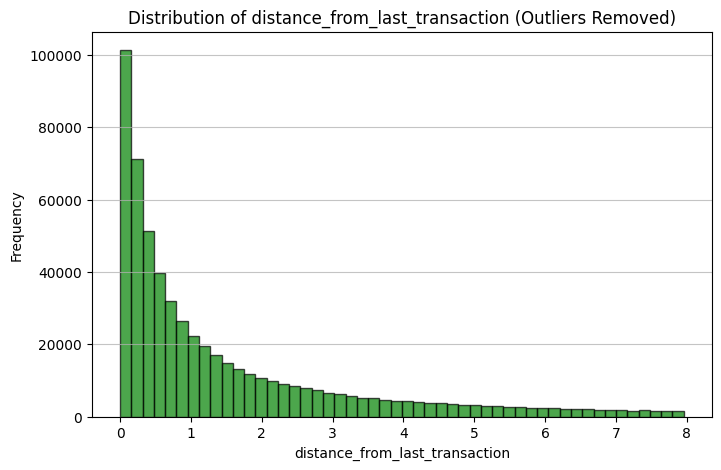

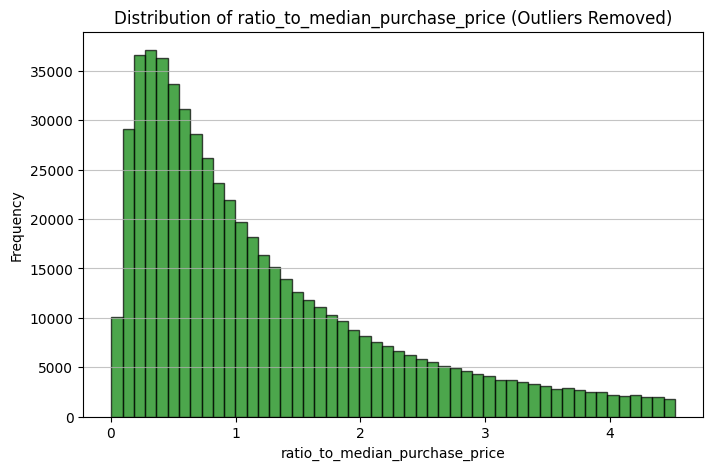

In [9]:
# Define a function to remove outliers using the IQR method
def remove_outliers(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Remove outliers from the training data
X_train_cleaned = remove_outliers(X_train.copy(), numerical_columns)

# Plot histograms for each numerical column after removing outliers
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(X_train_cleaned[column], bins=50, color='green', alpha=0.7, edgecolor='black')
    plt.title(f'Distribution of {column} (Outliers Removed)')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [10]:
import numpy as np

# Create 4 nonlinear predictors as combinations of the existing features
X_train_cleaned['distance_ratio'] = X_train_cleaned['distance_from_home'] / (X_train_cleaned['distance_from_last_transaction'] + 1e-5)
X_train_cleaned['distance_product'] = X_train_cleaned['distance_from_home'] * X_train_cleaned['distance_from_last_transaction']
X_train_cleaned['log_ratio_to_median'] = np.log1p(X_train_cleaned['ratio_to_median_purchase_price'])
X_train_cleaned['sqrt_distance_from_home'] = np.sqrt(X_train_cleaned['distance_from_home'])

X_train_cleaned

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer_N,repeat_retailer_Y,used_chip_N,used_chip_Y,used_pin_number_N,used_pin_number_Y,online_order_N,online_order_Y,distance_ratio,distance_product,log_ratio_to_median,sqrt_distance_from_home
566853,36.217183,0.247838,0.181411,False,True,False,True,True,False,False,True,146.126417,8.976005,0.166709,6.018071
382311,20.673837,0.573091,0.663585,False,True,False,True,True,False,False,True,36.073630,11.847992,0.508975,4.546849
241519,4.785209,2.389048,3.537959,False,True,False,True,True,False,False,True,2.002969,11.432092,1.512477,2.187512
719220,5.911469,1.238674,0.283680,False,True,True,False,True,False,False,True,4.772379,7.322383,0.249731,2.431351
905718,31.651844,1.688151,0.174281,False,True,True,False,True,False,True,False,18.749307,53.433084,0.160656,5.625997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644167,7.209949,0.771955,1.086937,False,True,False,True,True,False,False,True,9.339737,5.565755,0.735697,2.685135
259178,0.539606,3.479517,0.129496,True,False,True,False,True,False,True,False,0.155080,1.877569,0.121772,0.734579
131932,20.473521,0.004376,0.915167,False,True,True,False,True,False,True,False,4668.206804,0.089587,0.649805,4.524768
671155,9.958865,0.168019,1.174115,False,True,True,False,True,False,False,True,59.268608,1.673282,0.776621,3.155767


In [13]:
X_test = X_test.copy()
X_test['distance_ratio'] = X_test['distance_from_home'] / (X_test['distance_from_last_transaction'] + 1e-5)
X_test['distance_product'] = X_test['distance_from_home'] * X_test['distance_from_last_transaction']
X_test['log_ratio_to_median'] = np.log1p(X_test['ratio_to_median_purchase_price'])
X_test['sqrt_distance_from_home'] = np.sqrt(X_test['distance_from_home'])

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define the pipeline with standardization and logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(penalty='l1', solver='saga', max_iter=10000))
])

# Define the parameter grid for lambda (C is the inverse of regularization strength)
param_grid = {
    'logistic__C': [0.05, 0.1, 1, 10, 100]
}

# Perform GridSearchCV to find the best lambda with a reduced dataset to avoid long runtime
# Reduce the size of the training data for faster computation
X_train_sampled = X_train_cleaned.sample(frac=0.1, random_state=42)
y_train_sampled = y_train.loc[X_train_sampled.index]  # Corrected to use y_train instead of y_train_cleaned

# Perform GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_sampled, y_train_sampled)

# Best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score

({'logistic__C': 0.1}, np.float64(0.9984172914847038))

In [29]:
# prompt: Evaluate the test performances of the above regression model

# Use the best model found by GridSearchCV on the full training data
best_model = grid_search.best_estimator_
best_model.fit(X_train_cleaned, y_train.loc[X_train_cleaned.index]) # Fit on the full cleaned training data

# Evaluate the model on the test set
y_pred = best_model.predict(X_test)

# Print evaluation metrics
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy on Test Set: 0.946735

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97    182557
           1       0.68      0.73      0.71     17443

    accuracy                           0.95    200000
   macro avg       0.83      0.85      0.84    200000
weighted avg       0.95      0.95      0.95    200000


Confusion Matrix:
 [[176602   5955]
 [  4698  12745]]


In [ ]:
X_test = X_test.copy()
X_test['distance_ratio'] = X_test['distance_from_home'] / (X_test['distance_from_last_transaction'] + 1e-5)
X_test['distance_product'] = X_test['distance_from_home'] * X_test['distance_from_last_transaction']
X_test['log_ratio_to_median'] = np.log1p(X_test['ratio_to_median_purchase_price'])
X_test['sqrt_distance_from_home'] = np.sqrt(X_test['distance_from_home'])

# Predict on the test set using the best model
y_test_pred = best_model.predict(X_test)

# Generate the classification report
classification_report_test = classification_report(y_test, y_test_pred)
classification_report_test

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9944 - loss: 0.0193 - val_accuracy: 0.9984 - val_loss: 0.0034
Epoch 2/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.9981 - loss: 0.0046 - val_accuracy: 0.9988 - val_loss: 0.0027
Epoch 3/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9983 - loss: 0.0039 - val_accuracy: 0.9988 - val_loss: 0.0031
Epoch 4/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.9985 - loss: 0.0035 - val_accuracy: 0.9987 - val_loss: 0.0029
Epoch 5/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.9987 - loss: 0.0031 - val_accuracy: 0.9991 - val_loss: 0.0023
Epoch 6/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - accuracy: 0.9987 - loss: 0.0031 - val_accuracy: 0.9987 - val_loss: 0.0028
Epoch 7/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - accuracy: 0.9988 - loss: 0.0029 - val_accuracy: 0.9985 - val_loss: 0.0031
Epoch 8/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 

In [16]:
# prompt: save the results in a parquet file

# Create a DataFrame from the predictions
# Since the model predicts probabilities, you might want to convert them to class labels (0 or 1)
y_pred_prob = model.predict(X_test_scaled)
y_pred_class = (y_pred_prob > 0.5).astype("int32")

# Create a DataFrame with the test features and predicted classes
results_df = X_test.copy() # Use the original X_test features for readability
results_df['predicted_fraud'] = y_pred_class
results_df['actual_fraud'] = y_test.values # Add actual labels for comparison

# Save the results to a Parquet file
results_df.to_parquet('fraud_prediction_results.parquet')

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


In [17]:
# prompt: Evaluate the test performances of the model using the classification report.

# Generate classification report
print(classification_report(y_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97    182557
           1       0.73      0.69      0.71     17443

    accuracy                           0.95    200000
   macro avg       0.85      0.83      0.84    200000
weighted avg       0.95      0.95      0.95    200000



In [23]:
# prompt: Fit a more complicated Neural Network by increasing the layer to 5 and number of neurons by 10 % and add an L1 penalization inside each layer.

from tensorflow.keras.regularizers import L1

# Define the neural network model with increased layers and neurons, and L1 regularization
# Calculate the number of neurons for the hidden layers (10% increase)
initial_neurons = 64
increased_neurons = int(initial_neurons * 1.10)

model = Sequential([
    Dense(increased_neurons, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=L1(0.001)),
    Dense(increased_neurons, activation='relu', kernel_regularizer=L1(0.001)),
    Dense(increased_neurons, activation='relu', kernel_regularizer=L1(0.001)),
    Dense(increased_neurons, activation='relu', kernel_regularizer=L1(0.001)),
    Dense(increased_neurons, activation='relu', kernel_regularizer=L1(0.001)),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train_cleaned, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# Create a DataFrame from the predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred_class = (y_pred_prob > 0.5).astype("int32")

# Create a DataFrame with the test features and predicted classes
results_df = X_test.copy()
results_df['predicted_fraud'] = y_pred_class
results_df['actual_fraud'] = y_test.values

# Save the results to a Parquet file
results_df.to_parquet('fraud_prediction_results_nn5l_l1.parquet')

# Generate classification report
print(classification_report(y_test, y_pred_class))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - accuracy: 0.9939 - loss: 0.1536 - val_accuracy: 0.9978 - val_loss: 0.0229
Epoch 2/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9978 - loss: 0.0211 - val_accuracy: 0.9964 - val_loss: 0.0208
Epoch 3/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.9982 - loss: 0.0176 - val_accuracy: 0.9983 - val_loss: 0.0159
Epoch 4/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step - accuracy: 0.9983 - loss: 0.0164 - val_accuracy: 0.9985 - val_loss: 0.0161
Epoch 5/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.9984 - loss: 0.0161 - val_accuracy: 0.9992 - val_loss: 0.0144
Epoch 6/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9983 - loss: 0.0157 - val_accuracy: 0.9987 - val_loss: 0.0152
Epoch 7/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step - accuracy: 0.9986 - loss: 0.0149 - val_accuracy: 0.9988 - val_loss: 0.0142
Epoch 8/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - accuracy: 

In [24]:
# prompt: Take the Neural NEtwork, and instead of adding the L1 Penalization add 2 Droput layers

from tensorflow.keras.layers import Dropout

# Define the neural network model with increased layers and neurons, and Dropout layers
# Calculate the number of neurons for the hidden layers (10% increase)
initial_neurons = 64
increased_neurons = int(initial_neurons * 1.10)

model = Sequential([
    Dense(increased_neurons, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),  # Add first Dropout layer
    Dense(increased_neurons, activation='relu'),
    Dropout(0.5),  # Add second Dropout layer
    Dense(increased_neurons, activation='relu'),
    Dense(increased_neurons, activation='relu'),
    Dense(increased_neurons, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train_cleaned, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# Create a DataFrame from the predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred_class = (y_pred_prob > 0.5).astype("int32")

# Create a DataFrame with the test features and predicted classes
results_df = X_test.copy()
results_df['predicted_fraud'] = y_pred_class
results_df['actual_fraud'] = y_test.values

# Save the results to a Parquet file
results_df.to_parquet('fraud_prediction_results_nn5l_dropout.parquet')

# Generate classification report
print(classification_report(y_test, y_pred_class))


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14375/14375 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - accuracy: 0.9917 - loss: 0.0258 - val_accuracy: 0.9978 - val_loss: 0.0052
Epoch 2/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9965 - loss: 0.0084 - val_accuracy: 0.9980 - val_loss: 0.0045
Epoch 3/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9971 - loss: 0.0074 - val_accuracy: 0.9980 - val_loss: 0.0049
Epoch 4/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9972 - loss: 0.0069 - val_accuracy: 0.9983 - val_loss: 0.0041
Epoch 5/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.9975 - loss: 0.0066 - val_accuracy: 0.9984 - val_loss: 0.0052
Epoch 6/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9976 - loss: 0.0060 - val_accuracy: 0.9989 - val_loss: 0.0029
Epoch 7/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9976 - loss: 0.0064 - val_accuracy: 0.9988 - val_loss: 0.0030
Epoch 8/10
14375/14375 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - accuracy: 0.9979 - lo